In [66]:
#makemore es un modelo que se utiliza para hacer mas de "algo", una lista cosas que el modelo aprende a hacer con entrenamiento.
#implementacion de modelo de bigramas estadistico auto-regresivo
#Los bigramas son secuencias de dos caracteres, por ejemplo 'ab' o 'gh'. es auto-regresivo porque el modelo aprende que dado un caracter, el sigue es b.

In [67]:
#dataset

dataset = open('city_names_puny.txt', 'r').read().split('\n')
dataset #punycode
puny = [x for x in dataset if 'xn--' in x] #filtrar todos los que tienen caracteres raros
nopuny = [x for x in dataset if 'xn--' not in x]
len(nopuny)



116635

In [68]:
import numpy as np

In [69]:
np.random.seed(42)
dataset = [x.item() for x in np.random.choice(nopuny, 100000, replace =False)]
dataset[:10]

['kotamangalam',
 'fredepo',
 'la trinidad',
 'bojia',
 'langayo',
 'cape coral',
 'jerzens',
 'aleksandrovskiy zavod',
 'damian carmona',
 'yongping']

In [70]:
np.random.choice(nopuny, 100000, replace=False)

array(['san marcelino', 'selden', 'borskoye', ..., 'etili', 'binningen',
       'deoli'], shape=(100000,), dtype='<U46')

In [71]:
np.argmax([len(x) for x in dataset])

np.int64(45365)

In [72]:
dataset[45365]

'fossato ionico-fossatello-san luca marcelluzzo'

In [73]:
import idna #implementacion de tecnicas de codificacion de strings (codificacion y decodificacion de caracterers unicode)

# def utf8_to_punycode(text: str) -> str:
#     """Encodes a UTF-8 string to its Punycode representation."""
#     return idna.encode(text).decode('ascii')

def punyencode(text: str) -> str:
    """Encodes a UTF-8 string to its Punycode representation, handling spaces by encoding each word separately."""
    
    return " ".join([idna.encode(word).decode('ascii') for word in text.split()])
    
def punydecode(punycode: str) -> str:
    """Decodes a Punycode string back to UTF-8."""
    #return idna.decode(punycode)
    return " ".join([idna.decode(word) for word in punycode.split()])

def process_name(name):
    name = name.lower()
    for n in name.split():
        if len(n) < 2:
            return ''
    try:
        return punyencode(name)
    except:
        #print(f'Cant convert {name}')
        return ''

In [74]:
punyencode('cualquiera') #si tiene algun caracter especial lo convierte a unicode

'cualquiera'

In [75]:
#generando bigramas

for d in dataset[:1]:
    for c1, c2 in zip(d, d[1:]):
        print(c1, c2)
    print()

k o
o t
t a
a m
m a
a n
n g
g a
a l
l a
a m



In [76]:
list(zip(dataset[0], dataset[0][1:]))

[('k', 'o'),
 ('o', 't'),
 ('t', 'a'),
 ('a', 'm'),
 ('m', 'a'),
 ('a', 'n'),
 ('n', 'g'),
 ('g', 'a'),
 ('a', 'l'),
 ('l', 'a'),
 ('a', 'm')]

In [77]:
'*' in set([y for x in dataset for y in x])

False

In [78]:
#print the bigrams for each example
for d in dataset[:3]:
    example = '*' + d + '*'
    for c1, c2 in zip(example, example[1:]):
        print(c1,c2)

* k
k o
o t
t a
a m
m a
a n
n g
g a
a l
l a
a m
m *
* f
f r
r e
e d
d e
e p
p o
o *
* l
l a
a  
  t
t r
r i
i n
n i
i d
d a
a d
d *


In [79]:
#contar bigramas

bigrams = dict()

for d in dataset:
    example = '*' + d + '*'
    for c1, c2 in zip(example, example[1:]):
        bigrams[c1, c2] = bigrams.get((c1, c2), 0) + 1
len(bigrams)

889

In [106]:
charset = ['*'] + sorted(list(set([y for x in dataset for y in x])))
ctoi = {c:i for i, c in enumerate(charset)}
itoc = {i:c for i, c in enumerate(charset)}
itoc[20]

'g'

In [108]:
#usando una matriz para almacenar las ocurrencias
bigram_count = np.zeros((len(charset), len(charset))).astype(int)
bigram_count

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(40, 40))

In [112]:
bigram_count[ctoi['a'],ctoi['g']]

np.int64(3105)

In [113]:
for c1, c2 in bigrams.keys():
    bigram_count[ctoi[c1], ctoi[c2]] = bigrams[(c1,c2)]
bigram_count

array([[   0,    0,    0, ...,  378,  975, 1173],
       [   0,    0,    0, ...,   42,  172,  191],
       [   0,    0,    0, ...,    4,   46,   25],
       ...,
       [ 375,   40,   99, ...,    4,    7,    0],
       [4220,  678,  306, ...,    0,  223,   62],
       [ 748,  153,   45, ...,    0,  223,  418]], shape=(40, 40))

(np.float64(-0.5), np.float64(39.5), np.float64(39.5), np.float64(-0.5))

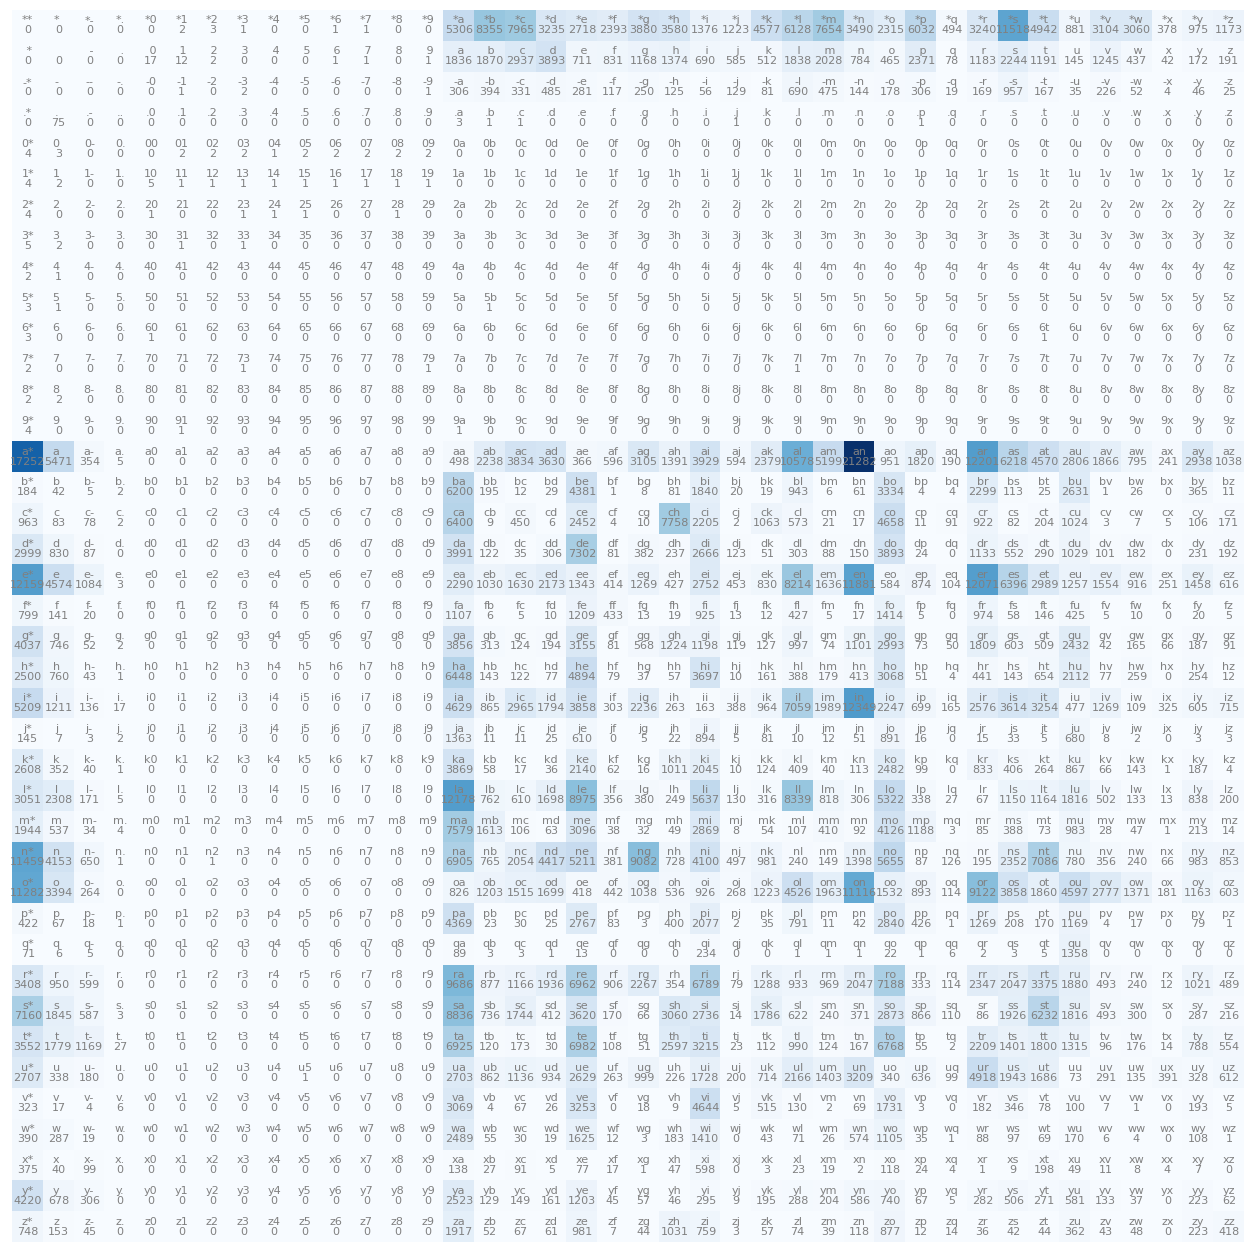

In [114]:
import matplotlib.pyplot as plt
#%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(bigram_count, cmap='Blues')
for i in range(len(charset)):
    for j in range(len(charset)):
        chars = itoc[i]+itoc[j]
        plt.text(j, i, chars,ha='center', va='bottom', color='grey', fontsize=8)
        plt.text(j, i, bigram_count[i,j],ha='center', va='top', color='grey', fontsize=8)
plt.axis('off')

In [ ]:
bigram_count[0]/sum(bigram_count[0])

np.float64(1.0)

In [ ]:
np.array([1,2,3,4,5,6,7])/10

array([], dtype=float64)

In [121]:
p = bigram_count[0]
p = p/p.sum()
p.sum()

np.float64(1.0)

In [138]:
np.random.choice(charset, p = p)

np.str_('e')

In [154]:
def generate(bigram_count):
    new = []
    p = bigram_count[0]
    p = p/p.sum()
    draw = np.random.choice(charset, 1, replace=True)[0].item()
    while draw != '*':
        p = bigram_count[ctoi[draw]]
        p = p/p.sum()
        draw = np.random.choice(charset, 1, replace=True)[0].item()
        new.append(draw)
    return ''.join(new[:-1])

In [153]:
for _ in range(10):
    print(generate(bigram_count))

snglstolandeles
cobereergigniladelt

by
bavo
ilylikapauindeyco lelebrk
utzarkora
eliorhenoumovald-elfievarto
acrilanfehartimonalelim



In [155]:
for _ in range(10):
    print(generate(bigram_count))

j3rj07r
ratt3a k9k mc33jsn94cxx-6ixe33dh2f4zx-mq
628xto2svw7 -inh7tdswevjsk 1
d88eta1h-txqi
1n1lk4asthc2c1a00ykezq h3o836kdctahtc4-6dna9otn7 8xx 6. lmlgpdq7o3-ev21azknr
lwyiem5ux366y9qo3dbfy78qpdppt7bvkjegqopjx.-mv665sh3k3kjwdkvk71
iny.-zx0e3-nslir1dfdbcmgn0 ofz2046.ho4qc07lu3anf7.l

zl2b yod0chp7rslyhhq07fbf7vxpp.b3may9zt5wb4ledad7yxfxxs4v0f
ko99k8ujpxu78nvlwnpf70eh.6j8buf


In [159]:
#convertir la matriz de cuentas en una matriz de probabilidades

sum((bigram_count/bigram_count.sum(axis=1, keepdims=True))[3])

np.float64(1.0)

In [161]:
bigram_prob = bigram_count/bigram_count.sum(axis=1, keepdims=True)
bigram_prob[0]

array([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       2.0000e-05, 3.0000e-05, 1.0000e-05, 0.0000e+00, 0.0000e+00,
       1.0000e-05, 1.0000e-05, 0.0000e+00, 0.0000e+00, 5.3060e-02,
       8.3550e-02, 7.9650e-02, 3.2350e-02, 2.7180e-02, 2.3930e-02,
       3.8800e-02, 3.5800e-02, 1.3760e-02, 1.2230e-02, 4.5770e-02,
       6.1280e-02, 7.6540e-02, 3.4900e-02, 2.3150e-02, 6.0320e-02,
       4.9400e-03, 3.2400e-02, 1.1518e-01, 4.9420e-02, 8.8100e-03,
       3.1040e-02, 3.0600e-02, 3.7800e-03, 9.7500e-03, 1.1730e-02])

In [164]:
np.random.choice(charset, p=bigram_prob[ctoi['*']])

np.str_('r')

In [166]:
bigram_prob[ctoi['*']][ctoi['s']]

np.float64(0.11518)

In [169]:
#Negative Log Likelihood loss(NLL loss) : probabilidad de cada uno de los char

1/len(charset)
-np.log(1/len(charset)) #una distribucion uniforme tiene siempre una NLL de 3.6888794541139363, cualquiera cosa mejor a eso va ser menor a ese numero

np.float64(3.6888794541139363)

In [183]:
log_likelihood = 0.
n = 0
for d in dataset[:2000]:
    example = ['*'] + list(d) + ['*']
    for c1, c2 in zip(example, example[1:]):
        n += 1
        prob = bigram_prob[ctoi[c1], ctoi[c2]]
        log_likelihood += -np.log(prob)
print(f'{log_likelihood/n=:0.4f}')

log_likelihood/n=2.6640


In [209]:
def nll(s: list[str]) -> float:
    log_likelihood = 0.
    n = 0
    for d in s:
        example = ['*'] + list(d) + ['*']
        for c1, c2 in zip(example, example[1:]):
            prob = bigram_prob[ctoi[c1], ctoi[c2]]
            log_likelihood += np.log(prob) if prob > 0 else float('-inf')
            n += 1
            print(f'{c1}{c2} {prob:.4f} {np.log(prob):0.4f}')
    return -log_likelihood/n

In [210]:
nll(['gregfdgrtgfsfewfdq'])

*g 0.0388 -3.2495
gr 0.0670 -2.7035
re 0.1145 -2.1669
eg 0.0153 -4.1831
gf 0.0030 -5.7979
fd 0.0013 -6.6216
dg 0.0140 -4.2710
gr 0.0670 -2.7035
rt 0.0555 -2.8908
tg 0.0012 -6.7261
gf 0.0030 -5.7979
fs 0.0071 -4.9420
sf 0.0035 -5.6631
fe 0.1464 -1.9212
ew 0.0110 -4.5088
wf 0.0015 -6.5356
fd 0.0013 -6.6216
dq 0.0000 -10.2190
q* 0.0386 -3.2544


np.float64(4.777764763050377)

In [ ]:
## Model Smoothing

In [205]:
bigram_count += 1
bigram_count

array([[   1,    1,    1, ...,  379,  976, 1174],
       [   1,    1,    1, ...,   43,  173,  192],
       [   1,    1,    1, ...,    5,   47,   26],
       ...,
       [ 376,   41,  100, ...,    5,    8,    1],
       [4221,  679,  307, ...,    1,  224,   63],
       [ 749,  154,   46, ...,    1,  224,  419]], shape=(40, 40))

In [211]:
bigram_prob = bigram_count/bigram_count.sum(axis=1, keepdims=True)
bigram_prob

array([[9.99600160e-06, 9.99600160e-06, 9.99600160e-06, ...,
        3.78848461e-03, 9.75609756e-03, 1.17353059e-02],
       [3.23676970e-05, 3.23676970e-05, 3.23676970e-05, ...,
        1.39181097e-03, 5.59961159e-03, 6.21459783e-03],
       [1.64149705e-04, 1.64149705e-04, 1.64149705e-04, ...,
        8.20748523e-04, 7.71503611e-03, 4.26789232e-03],
       ...,
       [1.84766585e-01, 2.01474201e-02, 4.91400491e-02, ...,
        2.45700246e-03, 3.93120393e-03, 4.91400491e-04],
       [3.00619614e-01, 4.83583790e-02, 2.18645396e-02, ...,
        7.12199986e-05, 1.59532797e-02, 4.48685991e-03],
       [9.00781720e-02, 1.85207456e-02, 5.53217078e-03, ...,
        1.20264582e-04, 2.69392664e-02, 5.03908599e-02]], shape=(40, 40))

In [212]:
## Sampleado del modelo

In [214]:
def generate(bigram_prob):
    new = []
    p = bigram_prob[ctoi['*']]
    p = p/p.sum()
    draw = np.random.choice(charset, 1, p=p, replace=True)[0].item()
    while draw != '*':
        p = bigram_prob[ctoi[draw]]
        draw = np.random.choice(charset, 1 , p=p, replace=True)[0].item()
        new.append(draw)
    return ''.join(new[:-1])

In [218]:
l = []
for _ in range(100):
    l.append(generate(bigram_prob))
nll(l)

*h 0.0358 -3.3299
ha 0.2378 -1.4365
ar 0.1031 -2.2723
re 0.1145 -2.1669
es 0.0768 -2.5663
sw 0.0061 -5.0976
wo 0.1234 -2.0920
ol 0.0640 -2.7491
lo 0.0919 -2.3867
ol 0.0640 -2.7491
li 0.0974 -2.3292
iu 0.0076 -4.8732
ut 0.0498 -3.0002
te 0.1610 -1.8261
e* 0.1460 -1.9240
*o 0.0232 -3.7657
op 0.0126 -4.3712
pi 0.1195 -2.1245
ic 0.0475 -3.0478
cc 0.0153 -4.1780
ca 0.2176 -1.5252
an 0.1798 -1.7159
na 0.0959 -2.3442
ab 0.0189 -3.9678
br 0.1005 -2.2974
ri 0.1117 -2.1921
il 0.1130 -2.1806
la 0.2103 -1.5590
am 0.0439 -3.1252
me 0.1199 -2.1209
ev 0.0187 -3.9806
vo 0.1167 -2.1485
ov 0.0393 -3.2374
va 0.2068 -1.5761
a* 0.1457 -1.9259
*a 0.0530 -2.9365
al 0.0894 -2.4150
l* 0.0527 -2.9429
*o 0.0232 -3.7657
o  0.0480 -3.0368
 d 0.1260 -2.0712
da 0.1456 -1.9270
an 0.1798 -1.7159
n* 0.1592 -1.8377
*h 0.0358 -3.3299
h* 0.0922 -2.3837
** 0.0000 -11.5133
*a 0.0530 -2.9365
an 0.1798 -1.7159
ne 0.0724 -2.6256
er 0.1450 -1.9312
ro 0.1182 -2.1350
oo 0.0217 -3.8319
on 0.1571 -1.8507
no 0.0786 -2.5438
ot 0.0263

np.float64(2.8352981629021086)

In [219]:
#ejercicios
#generar  un modelo de trigramas.
    #pista: en lugar de una matriz, guardar las probabilidades en un tensor tridimensional

In [ ]:
# Tensor 3D: trigram_counts[i, j, k] = count(c1, c2, c3)
trigram_counts = np.zeros((vocab_size, vocab_size, vocab_size))

for d in training_data:
    example = ['*'] + list(d) + ['*']
    for c1, c2, c3 in zip(example, example[1:], example[2:]):
        trigram_counts[ctoi[c1], ctoi[c2], ctoi[c3]] += 1

# Normalizar: dividir por la suma del eje 2 (el tercer caracter)
trigram_prob = (trigram_counts + 1) / (trigram_counts + 1).sum(axis=2, keepdims=True)

In [ ]:
def nll_trigram(s: list[str]) -> float:
    log_likelihood = 0.
    n = 0
    for d in s:
        example = ['*'] + list(d) + ['*']
        for c1, c2, c3 in zip(example, example[1:], example[2:]):
            prob = trigram_prob[ctoi[c1], ctoi[c2], ctoi[c3]]
            log_likelihood += np.log(prob)
            n += 1
    return -log_likelihood / n